In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

### describe() - 요약통계
기본 값으로 **수치형(Numerical)** 컬럼에 대한 통계표
- count : 데이터 개수
- mean : 평균
- std : 표준편차
- min : 최솟값
- max : 최댓값

In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- count : 데이터 개수
- unique : 고유 데이터의 값 개수
- top : 가장 많이 출현한 데이터 개수
- freq : 가장 많이 출현한 데이터의 빈도 수 

In [4]:
df.describe(include = 'object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


### count() - 개수

In [5]:
df.count()

survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64

In [6]:
df['age'].count()

714

### mean() - 평균

In [8]:
df.mean(numeric_only = True) # string이 섞여 있을 경우 에러발생

survived       0.383838
pclass         2.308642
age           29.699118
sibsp          0.523008
parch          0.381594
fare          32.204208
adult_male     0.602694
alone          0.602694
dtype: float64

In [9]:
df['age'].mean()

29.69911764705882

In [10]:
condition = df['adult_male'] == True
df.loc[condition, 'age'].mean()

33.17312348668281

### skipna = True 옵션
``skipna = True`` 기본값으로 설정\
``skipna = False``로 설정되어 있다면, NaN값이 있는 columndms NaN으로 출력

In [12]:
df.mean(skipna=False, numeric_only = True)

survived       0.383838
pclass         2.308642
age                 NaN
sibsp          0.523008
parch          0.381594
fare          32.204208
adult_male     0.602694
alone          0.602694
dtype: float64

In [13]:
df.mean(skipna=True, numeric_only = True)

survived       0.383838
pclass         2.308642
age           29.699118
sibsp          0.523008
parch          0.381594
fare          32.204208
adult_male     0.602694
alone          0.602694
dtype: float64

### median() - 중앙값
**오름차순**으로 정렬했을 때 중앙값\
**짝수**개의 데이터가 있을 때 가운데 2개 중앙 데이터의 **평균값**

In [15]:
pd.Series([3, 4, 5, 1, 2]).median()

3.0

In [18]:
pd.Series([3, 4, 5, 1, 2, 6]).median()

3.5

### sum() - 합계

In [19]:
df.sum(numeric_only = True)

survived        342.0000
pclass         2057.0000
age           21205.1700
sibsp           466.0000
parch           340.0000
fare          28693.9493
adult_male      537.0000
alone           537.0000
dtype: float64

In [20]:
df['fare'].sum()

28693.9493

### cumsum() - 누적합, cumprod() - 누적곱

In [21]:
df['age'].cumsum()

0         22.00
1         60.00
2         86.00
3        121.00
4        156.00
         ...   
886    21128.17
887    21147.17
888         NaN
889    21173.17
890    21205.17
Name: age, Length: 891, dtype: float64

In [22]:
df['age'].cumprod()

/Users/heeju/.pyenv/versions/3.11.5/lib/python3.11/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


0            22.0
1           836.0
2         21736.0
3        760760.0
4      26626600.0
          ...    
886           inf
887           inf
888           NaN
889           inf
890           inf
Name: age, Length: 891, dtype: float64

### var() - 분산
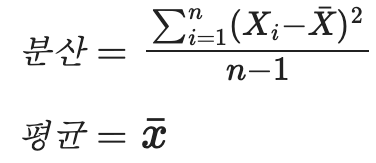

In [26]:
# 평균
fare_mean = df['fare'].mean()

# 분산
fare_var = ((df['fare'] - fare_mean) ** 2).sum() / (df['fare'].count() - 1)
fare_var

2469.436845743116

In [27]:
df['fare'].var()

2469.436845743116

### std() - 표준편차
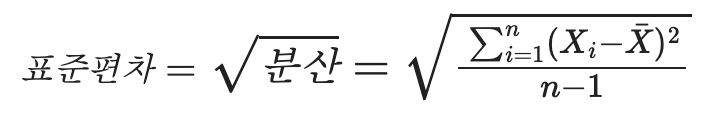

In [28]:
np.sqrt(df['fare'].var())

49.6934285971809

In [29]:
df['fare'].std()

49.6934285971809

### min() - 최소값, man() - 최대값

In [30]:
df['age'].min()

0.42

In [31]:
df['age'].max()

80.0

### agg (aggregation) 
통합 통계 적용 (복수 통계 함수 적용)

In [32]:
df['age'].agg(['min', 'max', 'count', 'mean'])

min        0.420000
max       80.000000
count    714.000000
mean      29.699118
Name: age, dtype: float64

In [35]:
df[['age', 'fare']].agg(['min', 'max', 'count', 'mean'])

,age,fare
min,0.420000,0.000000
max,80.000000,512.329200
count,714.000000,891.000000
mean,29.699118,32.204208


### quantile() - 분위
주어진 데이터를 동등한 크기로 분할하는 지점

In [38]:
# 하위 10%
df['age'].quantile(0.1)

14.0

### unique() - 고유값, nunique() - 고유값 개수

In [39]:
df['who'].unique()

array(['man', 'woman', 'child'], dtype=object)

In [41]:
df['who'].nunique()

3

### mode() - 최빈값

In [44]:
# 값만 출력하고 싶을 때 [0]번째 출력
df['who'].mode()[0]

'man'

In [45]:
df['deck'].mode()

0    C
Name: deck, dtype: category
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

### corr() - 상관관계
- -1 ~ 1 사이의 범위
- -1에 가까울수록 반비례 관계, 1에 가까울수록 정비례 관계

In [46]:
df.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


In [47]:
df.corr(numeric_only=True)['survived']

survived      1.000000
pclass       -0.338481
age          -0.077221
sibsp        -0.035322
parch         0.081629
fare          0.257307
adult_male   -0.557080
alone        -0.203367
Name: survived, dtype: float64